# Analysis of British Road Network Use

The assignment will focus on data aggregation and grouping using Pandas library, followed by the creation of plots using Bokeh library.

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

### Importing Libraries
First of all, we will import `pandas` and `matplotlib` `pyplot`. It’s common to import pandas with the alias `pd`and matplotlib with alias `plt`. To embed plots in a cell in the notebook use `%matplotlib inline`. 

The `matplotlib_axes_logger.setLevel('ERROR')` code prevents some unnecessary warnings from showing.

The `warnings.filterwarnings('ignore')` suppressing all other general warnings except errors.

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib.axes._axes import _log as matplotlib_axes_logger # Suppress Matplotlib specific warnings except errors
matplotlib_axes_logger.setLevel('ERROR')

import warnings
warnings.filterwarnings('ignore') # Suppressing all other general warnings except errors

### About the Dataset

You will be analysing a dataset from the UK [Department for Transport](https://data.gov.uk/dataset/208c0e7b-353f-4e2d-8b7a-1a7118467acc/gb-road-traffic-counts) on the road network use by different types of vehicles from 1993-2018. Further information on the fields in the dataset can be found in this [guide](https://storage.googleapis.com/dft-statistics/road-traffic/all-traffic-data-metadata.pdf), although this isn't necessary for completion of the assignment.

### Importing the Dataset

Use `.read_csv()` to get our dataset `data/region_traffic.csv` and assign to DataFrame `df`:

In [2]:
df = pd.read_csv('data/region_traffic.csv')

Running `df.head()`, `df.tail()` and `df.info()` will show us how the DataFrame is structured:

In [3]:
df.head()

,year,region_id,name,ons_code,road_category_id,total_link_length_km,total_link_length_miles,pedal_cycles,two_wheeled_motor_vehicles,cars_and_taxis,buses_and_coaches,lgvs,all_hgvs,all_motor_vehicles
0,1993,1,South West,E12000009,1,301.339,187.24,0.000000e+00,1.398776e+07,2.684992e+09,2.794561e+07,3.099538e+08,4.289609e+08,3.465840e+09
1,1993,1,South West,E12000009,3,993.586,617.39,3.579808e+06,2.952583e+07,2.837007e+09,2.061703e+07,3.204389e+08,2.771219e+08,3.484710e+09
2,1993,1,South West,E12000009,4,3874.924,2407.77,3.866325e+07,1.018629e+08,6.487077e+09,7.924033e+07,7.524918e+08,3.733318e+08,7.794004e+09
3,1993,1,South West,E12000009,5,3290.200,2044.44,2.435899e+07,3.591588e+07,1.955830e+09,2.787347e+07,2.723172e+08,7.177956e+07,2.363717e+09
4,1993,1,South West,E12000009,6,40291.500,25035.98,1.613508e+08,1.086337e+08,5.709405e+09,8.934448e+07,6.965099e+08,1.443973e+08,6.748291e+09


In [4]:
df.tail()

,year,region_id,name,ons_code,road_category_id,total_link_length_km,total_link_length_miles,pedal_cycles,two_wheeled_motor_vehicles,cars_and_taxis,buses_and_coaches,lgvs,all_hgvs,all_motor_vehicles
1574,2018,11,North East,E12000001,2,2.80,1.74,0.000000e+00,2.048791e+05,3.611546e+07,3.353402e+05,4.528347e+06,7.728592e+05,4.195688e+07
1575,2018,11,North East,E12000001,3,350.40,217.73,2.216186e+05,1.137795e+07,2.120027e+09,8.819422e+06,4.273893e+08,1.954551e+08,2.763069e+09
1576,2018,11,North East,E12000001,4,1453.90,903.41,1.431639e+07,2.332355e+07,3.413169e+09,3.537577e+07,5.720052e+08,1.350186e+08,4.178892e+09
1577,2018,11,North East,E12000001,5,1346.15,836.46,5.017630e+06,5.456948e+06,5.974809e+08,7.556679e+06,9.401424e+07,8.763506e+06,7.132722e+08
1578,2018,11,North East,E12000001,6,13156.23,8174.90,7.034451e+07,3.456422e+07,3.108541e+09,9.114751e+07,5.892073e+08,3.369251e+07,3.857152e+09


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579 entries, 0 to 1578
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1579 non-null   int64  
 1   region_id                   1579 non-null   int64  
 2   name                        1579 non-null   object 
 3   ons_code                    1579 non-null   object 
 4   road_category_id            1579 non-null   int64  
 5   total_link_length_km        1579 non-null   float64
 6   total_link_length_miles     1579 non-null   float64
 7   pedal_cycles                1579 non-null   float64
 8   two_wheeled_motor_vehicles  1579 non-null   float64
 9   cars_and_taxis              1579 non-null   float64
 10  buses_and_coaches           1579 non-null   float64
 11  lgvs                        1579 non-null   float64
 12  all_hgvs                    1579 non-null   float64
 13  all_motor_vehicles          1579 

### Exploratory Analysis

**Q1. Group `df` by Year and Aggregate Specific Columns**

Create a DataFrame called `year` by grouping the `df` DataFrame by the `'year'` column. The resulting `year` DataFrame should include the columns `['pedal_cycles', 'cars_and_taxis', 'all_hgvs']`, with each column containing the `.sum()` of its values for each year.


See below code syntax for some guidance:
```python
year = DataFrame_Name.groupby(by=...)[list_of_cols].sum() 
```

In [6]:
#add your code below
#year =

# Grouping by 'year' and summing the specified columns
year = df.groupby(by='year')[['pedal_cycles', 'cars_and_taxis', 'all_hgvs']].sum()

print(year)

      pedal_cycles  cars_and_taxis      all_hgvs
year                                            
1993  2.489981e+09    2.100849e+11  1.507144e+10
1994  2.495693e+09    2.143886e+11  1.539442e+10
1995  2.573601e+09    2.181758e+11  1.581009e+10
1996  2.531690e+09    2.236457e+11  1.630137e+10
1997  2.536137e+09    2.272964e+11  1.668684e+10
1998  2.456836e+09    2.302792e+11  1.723609e+10
1999  2.534734e+09    2.345330e+11  1.747849e+10
2000  2.574585e+09    2.336574e+11  1.753572e+10
2001  2.608860e+09    2.368867e+11  1.742001e+10
2002  2.707001e+09    2.426824e+11  1.757117e+10
2003  2.755144e+09    2.423140e+11  1.765987e+10
2004  2.558371e+09    2.449631e+11  1.819330e+10
2005  2.680653e+09    2.439972e+11  1.798489e+10
2006  2.797313e+09    2.469057e+11  1.804688e+10
2007  2.550980e+09    2.472724e+11  1.818077e+10
2008  2.839879e+09    2.454109e+11  1.777312e+10
2009  2.966308e+09    2.447908e+11  1.631027e+10
2010  3.003657e+09    2.397883e+11  1.636518e+10
2011  3.070393e+09  

**Q2. Analyse the Change Over Time of Transport Modes Relative to Their 1993 Values**

We want to look at the change over time of each of these forms of transport relative to the earliest values (year 1993). 
To do so, we will create an *index*. An index allows us to inspect the growth over time of a variable relative to some starting value (known as the *base*). By convention, this starting value is `100.0`. If the value of our variable doubles in some future time period, then the value of our index in that future time period would be `200.0`. 


Please note below code create a new DataFrame called `year_index` as a `.copy()` of `year`.
Here **1993** is selected as the **base year**. This means that all values for 1993 should be equal to `100.0`, all subsequent years should be relative to that


See below code syntax for some guidance:
```python
base = year_index.iloc[0]
year_index = (year_index/base)*100
```
Below snippet showcases how the data in `year_index` DataFrame should look like after the changes, you do not need to apply any rounding.

```python
	pedal_cycles	cars_and_taxis	all_hgvs
year			
1993	100.000000	100.000000	100.000000
1994	100.229413	102.048581	102.143030
1995	103.358260	103.851256	104.900983
1996	101.675079	106.454909	108.160667
....
....
```

Please note you have been provided with the code for this question to carry out the necessary data manipulation work. Simply uncomment the lines of code and run the code cell to produce the desired results. 

In [7]:
#add your code below

year_index = year.copy()
base = year_index.iloc[0]
year_index = (year_index/base)*100
year_index.head()



,pedal_cycles,cars_and_taxis,all_hgvs
year,,,
1993,100.000000,100.000000,100.000000
1994,100.229413,102.048581,102.143030
1995,103.358260,103.851256,104.900983
1996,101.675079,106.454909,108.160667
1997,101.853694,108.192646,110.718300


**Q3. Create a Line Plot to Analyse Trends in Transport Modes Over Time**

Using the `year_index` DataFrame, generate a line plot to visualise the trends of different transport modes over time. Utilise the Pandas `.plot()` method with `kind='line'` to create the visualisation and save the resulting plot to a variable named `yi_fig`.


Begin by executing `plt.figure()` to initialise a new figure. This ensures that properties from previous plots are not overwritten in memory, allowing KATE to evaluate them correctly. 


See below code syntax for some guidance:
```python
plt.figure()
yi_fig = DataFrame_Name.plot(kind='line');
```

**Important:** Do not include any additional arguments when using the `.plot()` method other than what's been specified in the question. This ensures consistency in the evaluation process. 

<Figure size 640x480 with 0 Axes>

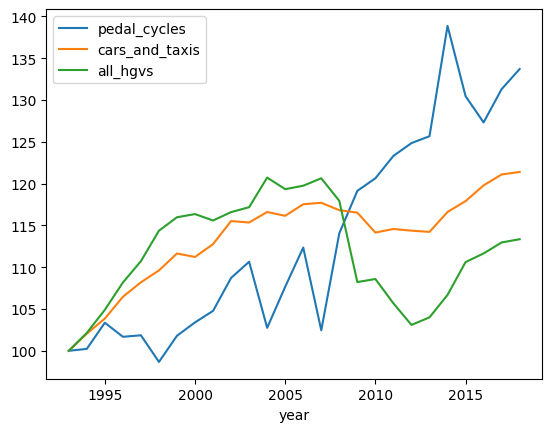

In [8]:
#add your code below
#plt.figure()
#yi_fig =

# Initializing a new figure
plt.figure()

# Creating the line plot and saving it to the variable yi_fig
yi_fig = year_index.plot(kind='line')


**Q4. Enhance the Line Plot with Additional Properties**

Now it’s time to enhance the above visualisation by adding additional properties to make it more informative and visually appealing.

Required Updates:
1. **Title**: Update the title to `'Change in road use by vehicle type over time'` with a font size of `14`.
2. **X-Axis Label**: Set the x-axis label to `'Year'` with a font size of `12`.
3. **Y-Axis Label**: Set the y-axis label to `'Road use by distance (1993 = 100)'` with a font size of `12`.
4. **Legend**: Position the legend in the `'upper left'` corner and set its title to `'Vehicle Type'`.
5. **X-Axis Ticks**: Update the x-axis ticks to display the values `[1993, 1998, 2003, 2008, 2013, 2018]`.

Enhancing the plot with these updates will provide a clearer and more professional visualisation.

Save the resulting updated plot to a variable named `yi_fig2`.


Begin by executing `plt.figure()` to initialise a new figure. This ensures that properties from previous plots are not overwritten in memory, allowing KATE to evaluate them correctly. 

See below code syntax for some guidance:
```python
plt.figure()
yi_fig2 = year_index.plot(kind='line')

plt.title('title', fontsize=14)
plt.xlabel('label', fontsize=12)
plt.ylabel('label', fontsize=12)
plt.legend(title='title', loc=...)
plt.xticks(ticks=[values])

plt.show()
```

**Important:** Do not include any additional arguments when using the `.plot()` method other than what's been specified in the question. This ensures consistency in the evaluation process. 

<Figure size 640x480 with 0 Axes>

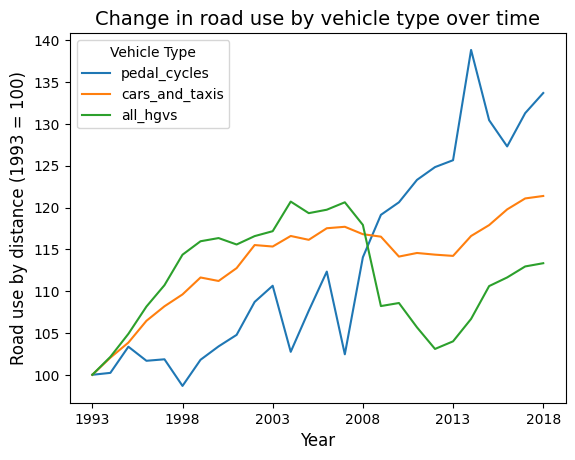

In [9]:
#add your code below
#plt.figure()
#yi_fig2 =

# Initializing a new figure
plt.figure()

# Creating the line plot
yi_fig2 = year_index.plot(kind='line')

# Adding the title, x-axis label, and y-axis label
plt.title('Change in road use by vehicle type over time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Road use by distance (1993 = 100)', fontsize=12)

# Updating the legend
plt.legend(title='Vehicle Type', loc='upper left')

# Updating the x-axis ticks
plt.xticks(ticks=[1993, 1998, 2003, 2008, 2013, 2018])

# Display the plot
plt.show()


**Q5. Create and Manipulate a DataFrame for 2018 Transport Data**

Create a DataFrame named `green_2018` by performing the following steps:

- Filter the `df` DataFrame to include only data for the year **2018**.
- Group the 2018 data by `name` and select the columns `['pedal_cycles', 'buses_and_coaches']` and calculate the `.sum()` for each group.
- Sort the resulting DataFrame in **descending** order based on the values in the `pedal_cycles` column.
- Divide all the values in the final DataFrame by `1000000` (to scale the data appropriately).

See below code syntax for some guidance:
```python
green_2018 = DataFrame_Name.groupby(by=...)[list_of_cols].sum().sort_values(by=..., ascending=False) / 1000000
```

In [10]:
#add your code below
#green_2018 =

# Filtering the data for the year 2018 and then grouping by 'name'
green_2018 = df[df['year'] == 2018].groupby(by='name')[['pedal_cycles', 'buses_and_coaches']].sum()

# Sorting the resulting DataFrame in descending order based on 'pedal_cycles'
green_2018 = green_2018.sort_values(by='pedal_cycles', ascending=False)

# Dividing all values by 1000000 to scale the data appropriately
green_2018 = green_2018 / 1000000


**Q6. Create a Horizontal Stacked Bar Chart from the `green_2018` DataFrame**

Using the `green_2018` DataFrame, create a *horizontal, stacked* bar chart to visualise the data. Assign the resulting plot to a variable named `green_bar`.

Begin by executing `plt.figure()` to initialise a new figure. This ensures that properties from previous plots are not overwritten in memory, allowing KATE to evaluate them correctly. 

See below code syntax for some guidance:
```python
plt.figure()
green_bar = DataFrame_Name.plot(stacked=True, kind='barh');
```
**Important:** Do not include any additional arguments when using the `.plot()` method other than what's been specified in the question. This ensures consistency in the evaluation process. 

<Figure size 640x480 with 0 Axes>

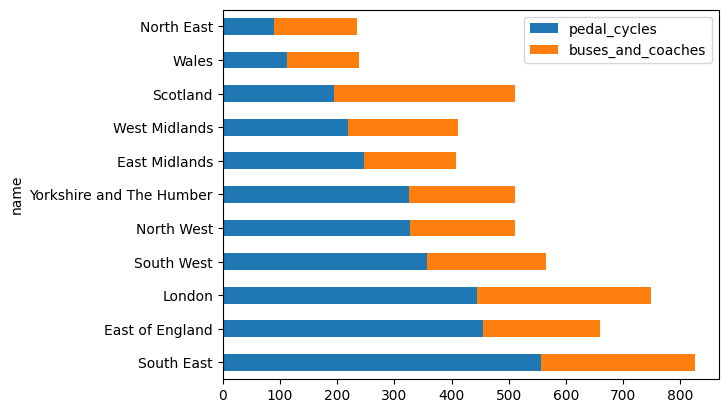

In [11]:
#add your code below
#plt.figure()
#green_bar =

# Initializing a new figure
plt.figure()

# Creating the horizontal stacked bar chart and saving it to green_bar
green_bar = green_2018.plot(stacked=True, kind='barh')


**Q7. Enhance the Stacked Bar Chart with Additional Properties**

Now it’s time to enhance the above visualisation by adding additional properties to make it more informative and visually appealing.

Required Updates:
1. **Title**: Update the title to `'Regional travel by bicycle and bus in 2018'` with a font size of `14`.
2. **X-Axis Label**: Set the x-axis label to `'Vehicle miles (millions)'` with a font size of `12`.
3. **Y-Axis Label**: Set the y-axis label to `'Region'` with a font size of `12`.

Enhancing the plot with these updates will provide a clearer and more professional visualisation.

Save the resulting updated plot to a variable named `green_bar2`.

Begin by executing `plt.figure()` to initialise a new figure. This ensures that properties from previous plots are not overwritten in memory, allowing KATE to evaluate them correctly. 

See below code syntax for some guidance:
```python
plt.figure()
green_bar2 = green_2018.plot(stacked=True, kind='barh')

plt.title('title', fontsize=14)
plt.xlabel('label', fontsize=12)
plt.ylabel('label', fontsize=12)

plt.show()
```

**Important:** Do not include any additional arguments when using the `.plot()` method other than what's been specified in the question. This ensures consistency in the evaluation process. 

<Figure size 640x480 with 0 Axes>

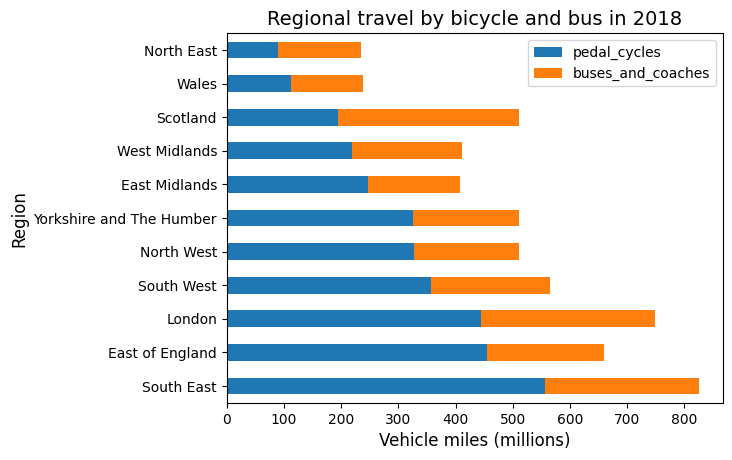

In [12]:
#add your code below
#plt.figure()
#green_bar2 =

# Initializing a new figure
plt.figure()

# Creating the horizontal stacked bar chart
green_bar2 = green_2018.plot(stacked=True, kind='barh')

# Adding the title, x-axis label, and y-axis label
plt.title('Regional travel by bicycle and bus in 2018', fontsize=14)
plt.xlabel('Vehicle miles (millions)', fontsize=12)
plt.ylabel('Region', fontsize=12)

# Display the plot
plt.show()


**Q8. Create the `length_motor` DataFrame with Grouped Data and a New Calculated Column**

Create a DataFrame called `length_motor` as follows:

**Step1:** Group `df` by `['year', 'name']` with columns for `['total_link_length_miles', 'all_motor_vehicles']` containing the `.sum()` of these:

See below code syntax for some guidance:
```python
length_motor = DataFrame_Name.groupby(by=...)[list_of_cols].sum() 
```
**Step2:** Then add a new column to `length_motor` DataFrame called **'million_vehicle_miles_per_road_mile'** which is equal to to the following calculation:
`(length_motor['all_motor_vehicles'] / 1000000) / length_motor['total_link_length_miles']`

In [13]:
#add your code below
#length_motor =

# Step 1: Group df by 'year' and 'name', then sum the columns 'total_link_length_miles' and 'all_motor_vehicles'
length_motor = df.groupby(by=['year', 'name'])[['total_link_length_miles', 'all_motor_vehicles']].sum()

# Step 2: Add a new column 'million_vehicle_miles_per_road_mile'
length_motor['million_vehicle_miles_per_road_mile'] = (length_motor['all_motor_vehicles'] / 1000000) / length_motor['total_link_length_miles']


**Q9. Creation of `reg_density` DataFrame Using a Pivot Table**

Here We are creating a new DataFrame called `reg_density` that organizes data from `length_motor` as follows:
- The **row index** will be `year`, representing each year from 1993 to 2018.
- The **columns** will be the unique values from `name`, representing each region.
- The **values** in the DataFrame will correspond to the `million_vehicle_miles_per_road_mile` for each year and region.


This task requires reshaping the `length_motor` DataFrame into a pivot table. You can use the Pandas `.pivot()` method to achieve this. Refer to the documentation for additional details on the method: [Pandas Pivot Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html).


Please note you have been provided with the code for this question to carry out the necessary data manipulation work. Simply uncomment the lines of code and run the code cell to produce the desired results. 

In [14]:
#add your code below

reg_density = length_motor.copy()
reg_density.reset_index(inplace=True)
reg_density = reg_density.pivot(index='year', columns='name', values='million_vehicle_miles_per_road_mile')
reg_density.head()



name,East Midlands,East of England,London,North East,North West,Scotland,South East,South West,Wales,West Midlands,Yorkshire and The Humber
year,,,,,,,,,,,
1993,1.064395,1.174043,2.140143,1.043946,1.293883,0.596892,1.514245,0.787532,0.678861,1.274398,1.092595
1994,1.087336,1.201897,2.164728,1.060768,1.314797,0.610051,1.547368,0.807469,0.693933,1.299053,1.114387
1995,1.107626,1.224337,2.161265,1.076316,1.339661,0.621164,1.577301,0.823139,0.706072,1.323180,1.135798
1996,1.140873,1.255611,2.177550,1.096399,1.371051,0.638259,1.625237,0.843202,0.722721,1.355891,1.166726
1997,1.163561,1.282051,2.187643,1.117606,1.396947,0.650531,1.661184,0.856932,0.737682,1.381401,1.185452


**Q10. Create the `density_index` DataFrame Based on `reg_density`**

As we did earlier when creating `year_index` DataFrame, let's create a new DataFrame called `density_index`, which is the same as `reg_density` except the all values are relative to the 1993 value, which should equal `100`. Do not modify `reg_density` DataFrame.

Please note you have been provided with the code for this question to carry out the necessary data manipulation work. Simply uncomment the lines of code and run the code cell to produce the desired results. 

In [15]:
#add your code below

density_index = reg_density.copy()
base = density_index.iloc[0]
density_index = (density_index/base)*100
density_index.head()



name,East Midlands,East of England,London,North East,North West,Scotland,South East,South West,Wales,West Midlands,Yorkshire and The Humber
year,,,,,,,,,,,
1993,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1994,102.155346,102.372441,101.148749,101.611422,101.616362,102.204494,102.187408,102.531619,102.220089,101.934657,101.994499
1995,104.061565,104.283762,100.986935,103.100738,103.538069,104.066285,104.164175,104.521338,104.008194,103.827818,103.954178
1996,107.185155,106.947597,101.747874,105.024561,105.964080,106.930430,107.329813,107.068876,106.460690,106.394598,106.784845
1997,109.316675,109.199620,102.219469,107.055930,107.965470,108.986346,109.703741,108.812309,108.664595,108.396338,108.498745


**Q11. Create a Line Plot from `density_index` and Assign it to `density_plot`**

To visualise the data in the `density_index` DataFrame, generate a line plot using the Pandas `.plot()` method with `kind='line'` and assign the resulting plot to a variable named `density_plot`. Ensure the plot is **15 by 8 inches** (width and height), and position the legend in the `'upper left'` corner with the title `'Regions'`.

Required Updates:
1. **X-Axis Label**: Set the x-axis label to `'Year'`.
2. **Y-Axis Label**: Set the y-axis label to `'Density Index'`.

Save the resulting updated plot to a variable named `density_plot`.

Begin by executing `plt.figure()` to initialise a new figure. This ensures that properties from previous plots are not overwritten in memory, allowing KATE to evaluate them correctly. 


See below code syntax for some guidance:
```python
plt.figure()
density_plot = DataFrame_Name.plot(kind='line', figsize=(15,8))
plt.xlabel('label')
plt.ylabel('label')
plt.legend(title='Regions', loc='upper left')
plt.show()
```

**Important:** Do not include any additional arguments when using the `.plot()` method other than what's been specified in the question. This ensures consistency in the evaluation process. 

<Figure size 640x480 with 0 Axes>

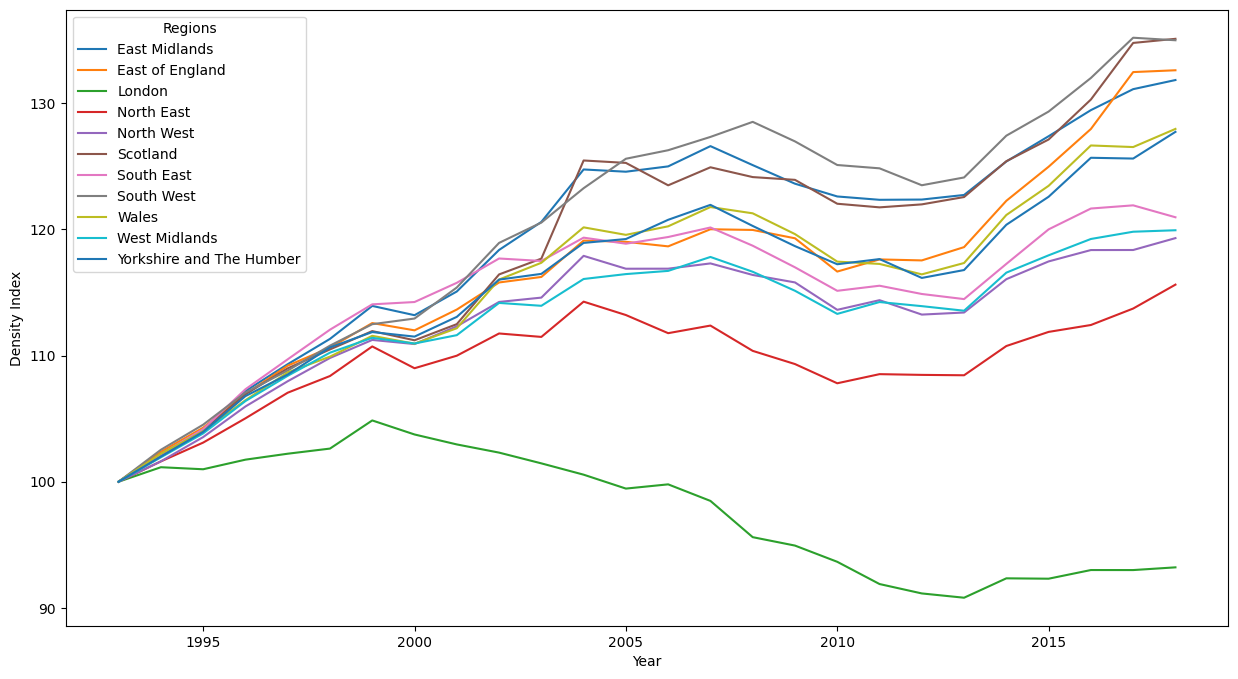

In [16]:
#add your code below
#plt.figure()
#density_plot =

# Initialize the figure
plt.figure()

# Create the line plot
density_plot = density_index.plot(kind='line', figsize=(15, 8))

# Update the labels and legend
plt.xlabel('Year')
plt.ylabel('Density Index')
plt.legend(title='Regions', loc='upper left')

# Display the plot
plt.show()
